## 02 — Comparing the LOD Levels

The four output files exist. Now we load them and answer:

1. How do the files differ in size, feature count, and coordinate count?
2. What does each level look like on a real map?
3. At what zoom does each level look correct — and at what zoom does it start to look wrong?

This is the quality check before we build the switching logic.

## Load All Four Levels

In [1]:
import json
from pathlib import Path

lod_dir = Path("../../data/lod")

lod_files = {
    "coarse":     "railroads_coarse.geojson",
    "medium":     "railroads_medium.geojson",
    "fine":       "railroads_fine.geojson",
    "extra_fine": "railroads_extra_fine.geojson",
}

lod_data = {}
for name, filename in lod_files.items():
    path = lod_dir / filename
    with open(path) as f:
        lod_data[name] = json.load(f)
    print(f"Loaded {name}: {len(lod_data[name]['features']):,} features")

Loaded coarse: 25,413 features
Loaded medium: 25,413 features
Loaded fine: 25,413 features
Loaded extra_fine: 25,413 features


## Summary Table — Size and Coordinate Count

In [2]:
print(f"{'Level':<12} {'Zoom':>6} {'Features':>10} {'Total pts':>12} {'File (MB)':>11}")
print("-" * 55)

zoom_ranges = {"coarse": "1-3", "medium": "4-6", "fine": "7-10", "extra_fine": "11+"}

for name, filename in lod_files.items():
    path = lod_dir / filename
    fc   = lod_data[name]
    n_features = len(fc["features"])
    total_pts  = sum(len(f["geometry"]["coordinates"]) for f in fc["features"])
    size_mb    = path.stat().st_size / 1_000_000
    zoom       = zoom_ranges[name]
    print(f"{name:<12} {zoom:>6} {n_features:>10,} {total_pts:>12,} {size_mb:>10.2f}")

# Also show the original for comparison
original_path = Path("../../data/ne_10m_railroads.geojson")
with open(original_path) as f:
    original = json.load(f)
orig_pts  = sum(len(f["geometry"]["coordinates"]) for f in original["features"])
orig_size = original_path.stat().st_size / 1_000_000
print("-" * 55)
print(f"{'original':<12} {'all':>6} {len(original['features']):>10,} {orig_pts:>12,} {orig_size:>10.2f}")

Level          Zoom   Features    Total pts   File (MB)
-------------------------------------------------------
coarse          1-3     25,413       50,836       9.55
medium          4-6     25,413       55,516       9.66
fine           7-10     25,413      124,844      11.34
extra_fine      11+     25,413      441,890      18.98
-------------------------------------------------------
original        all     25,413    1,396,480      43.31


## Visual Comparison — One Level at a Time

Display each LOD level on a map. Pan and zoom to see where it starts to look correct and where it breaks down.

In [6]:
from ipyleaflet import Map, GeoJSON
import ipywidgets as widgets

# Change this to switch between levels: "coarse", "medium", "fine", "extra_fine"
level = "coarse"
#level = "medium"
#level = "fine"
#level = "extra_fine"


level_zoom = {"coarse": 2, "medium": 4, "fine": 7, "extra_fine": 10}

m = Map(center=[20, 0], zoom=level_zoom[level])
layer = GeoJSON(
    data=lod_data[level],
    style={"color": "#cc3300", "weight": 1.5, "opacity": 0.8}
)
m.add(layer)

print(f"Showing: {level}  |  {len(lod_data[level]['features']):,} features")
m

Showing: coarse  |  25,413 features


Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

Try each level at its intended zoom range. Then deliberately zoom in too far on the coarse level — you should see the simplification artifacts clearly: straight lines where there should be curves.

## Side-by-Side Comparison — One Region

To see the difference sharply, let's crop to a small geographic area and display all four levels.

We filter to features whose bounding box falls within Europe (roughly).

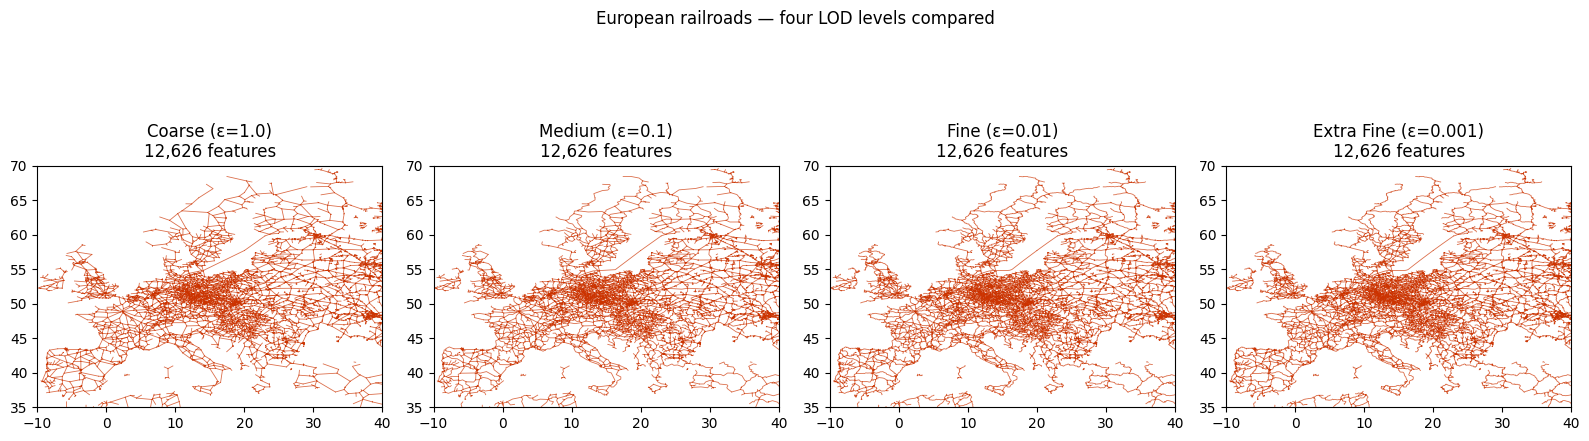

In [7]:
import matplotlib.pyplot as plt

# Europe bounding box [lon_min, lat_min, lon_max, lat_max]
europe = (-10, 35, 40, 70)

def coords_in_bbox(coords, bbox):
    lon_min, lat_min, lon_max, lat_max = bbox
    return any(
        lon_min <= c[0] <= lon_max and lat_min <= c[1] <= lat_max
        for c in coords
    )

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
titles = ["Coarse (ε=1.0)", "Medium (ε=0.1)", "Fine (ε=0.01)", "Extra Fine (ε=0.001)"]

for ax, (name, _), title in zip(axes, lod_files.items(), titles):
    europe_features = [
        f for f in lod_data[name]["features"]
        if coords_in_bbox(f["geometry"]["coordinates"], europe)
    ]
    for f in europe_features:
        xs = [c[0] for c in f["geometry"]["coordinates"]]
        ys = [c[1] for c in f["geometry"]["coordinates"]]
        ax.plot(xs, ys, '-', color='#cc3300', linewidth=0.6, alpha=0.7)
    ax.set_xlim(europe[0], europe[2])
    ax.set_ylim(europe[1], europe[3])
    ax.set_title(f"{title}\n{len(europe_features):,} features")
    ax.set_aspect('equal')

plt.suptitle('European railroads — four LOD levels compared', y=1.02)
plt.tight_layout()
plt.show()

The coarse level will show far fewer features (scalerank filter) and angular lines. The extra fine level should look nearly identical to the original.

## Exercise A

Pick one specific railroad feature that appears in all four LOD files — use the `rwdb_rr_id` property to find the same feature across files.

Plot that single feature at all four simplification levels on one chart. Label each with its point count.

In [ ]:
# Find a feature by rwdb_rr_id that exists in all four LOD levels
# Plot it at all four simplification levels
# Your code here

In [10]:
import json
from pathlib import Path

lod_dir = Path("../../data/lod")

lod_files = {
    "coarse":     "railroads_coarse.geojson",
    "medium":     "railroads_medium.geojson",
    "fine":       "railroads_fine.geojson",
    "extra_fine": "railroads_extra_fine.geojson",
}

lod_data = {}
for name, filename in lod_files.items():
    path = lod_dir / filename
    with open(path) as f:
        lod_data[name] = json.load(f)
    print(f"Loaded {name}: {len(lod_data[name]['features']):,} features")
# Find common rwdb_rr_id
common_ids = set()
for lod_file in lod_data.values():
    common_ids.update(feature['properties']['rwdb_rr_id'] for feature in lod_file['features'])
target_id = list(common_ids)[0]
print(f"Target ID found in all levels: {target_id}")

Loaded coarse: 25,413 features
Loaded medium: 25,413 features
Loaded fine: 25,413 features
Loaded extra_fine: 25,413 features
Target ID found in all levels: 0


In [ ]:
for ax, (name, _), title in zip(axes, lod_files.items(), titles):
    europe_features = [
        f for f in lod_data[name]["features"]
        if coords_in_bbox(f["geometry"]["coordinates"], europe)
    ]
    for f in europe_features:
        xs = [c[0] for c in f["geometry"]["coordinates"]]
        ys = [c[1] for c in f["geometry"]["coordinates"]]
        ax.plot(xs, ys, '-', color='#cc3300', linewidth=0.6, alpha=0.7)
    ax.set_xlim(europe[0], europe[2])
    ax.set_ylim(europe[1], europe[3])
    ax.set_title(f"{title}\n{len(europe_features):,} features")
    ax.set_aspect('equal')

plt.suptitle('European railroads — four LOD levels compared', y=1.02)
plt.tight_layout()
plt.show()

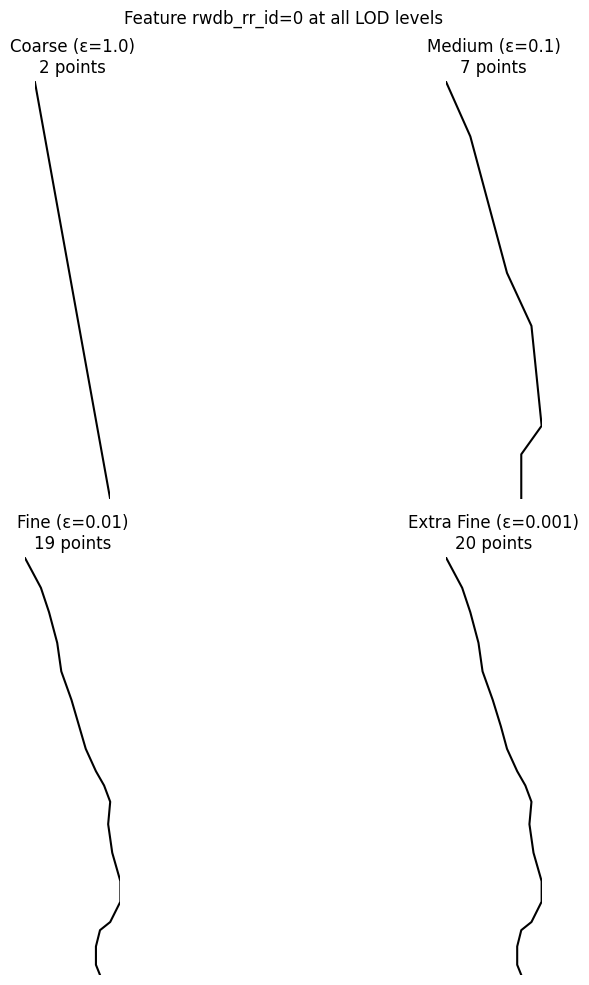

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
levels = ["coarse", "medium", "fine", "extra_fine"]
titles = ["Coarse (ε=1.0)", "Medium (ε=0.1)", "Fine (ε=0.01)", "Extra Fine (ε=0.001)"]

for ax, level, title in zip(axes.flat, levels, titles):
    # Find the feature with the target rwdb_rr_id in this LOD level
    feature = next((f for f in lod_data[level]["features"] if f["properties"]["rwdb_rr_id"] == target_id), None)
    if feature:
        coords = feature["geometry"]["coordinates"]
        xs = [c[0] for c in coords]
        ys = [c[1] for c in coords]
        ax.plot(xs, ys, '-', color='black', linewidth=1.5)
        ax.set_title(f"{title}\n{len(coords)} points")
        ax.set_xlim(min(xs), max(xs))
        ax.set_ylim(min(ys), max(ys))
        ax.set_aspect('equal')
    else:
        ax.set_title(f"{title}\nFeature not found")
    ax.axis('off')

plt.suptitle(f'Feature rwdb_rr_id={target_id} at all LOD levels', y=0.98)
plt.tight_layout()
plt.show()

## Exercise B

Calculate the **compression ratio** for each LOD level — the ratio of original coordinate count to simplified coordinate count for the features they share.

Then answer: which level gives the best size reduction per unit of visual quality loss?

In [ ]:
# Calculate compression ratio per LOD level
# Your code here

In [6]:
# lod_data and original are already loaded from previous cells
# Create a dict of original features by rwdb_rr_id for quick lookup
orig_features = {f['properties']['rwdb_rr_id']: f for f in original['features']}

# Calculate compression ratios for each LOD level based on shared features
results = {}
for lod_name in lod_files.keys():
    lod_features = lod_data[lod_name]['features']
    # Find shared features (those with matching rwdb_rr_id in original)
    shared_features = [f for f in lod_features if f['properties']['rwdb_rr_id'] in orig_features]
    
    if not shared_features:
        ratio = float('inf')
    else:
        # Sum original coordinate counts for shared features
        total_orig_coords = sum(len(orig_features[f['properties']['rwdb_rr_id']]['geometry']['coordinates']) for f in shared_features)
        # Sum LOD coordinate counts for shared features
        total_lod_coords = sum(len(f['geometry']['coordinates']) for f in shared_features)
        # Compression ratio: original coords / LOD coords
        ratio = total_orig_coords / total_lod_coords if total_lod_coords > 0 else float('inf')
    
    results[lod_name] = ratio
    print(f"{lod_name}: {ratio:.2f}:1")

# Analysis: Coarse gives highest compression but lowest quality; extra_fine gives least compression but highest quality.
# Best balance (size reduction per quality loss) is subjective, but medium or fine often provide good trade-offs.


coarse: 27.46:1
medium: 25.14:1
fine: 11.18:1
extra_fine: 3.16:1


## Check Your Understanding

The coarse level has far fewer features than the other levels because of the `scalerank <= 4` filter.

If a user zooms into a region that has no coarse-level features (e.g. a small country whose railroads are all scalerank 5+), what will they see? And what does this tell us about a limitation of the simple scalerank filter approach?

Write a 2–3 sentence answer.

---

If a user zooms into a region that has no coarse-level features (e.g. a small country whose railroads are all scalerank 5+), they will see a blank map, a map with missing data, or a significant visual discontinuity. Even if detailed, lower-level data (scalerank 5-10) exists, the map will appear empty or significantly less dense than surrounding regions because the scalerank <= 4 filter hides any feature not ranked 1–4

## Next

In [Module 03 — Bounding Box Culling](../03-Bounding_Box_Culling/README.md), we add viewport filtering — so we only render the features the user can actually see.